In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Shape of x_mat_full: (500, 3)
Shape of y: (500,)


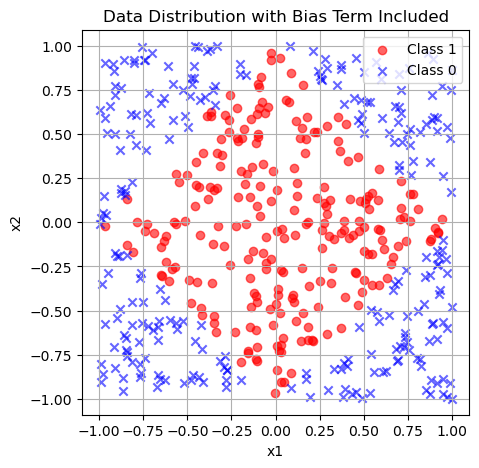

In [3]:
num_obs = 500

# Generate 2D input features from uniform distribution [-1, 1]
x_mat_1 = np.random.uniform(-1, 1, size=(num_obs, 2))

# Add bias term (column of ones)
x_mat_bias = np.ones((num_obs, 1))
x_mat_full = np.concatenate((x_mat_1, x_mat_bias), axis=1)

# Generate binary target variable: 1 if sum of abs(x1) + abs(x2) < 1, else 0
y = (np.abs(x_mat_full[:, 0]) + np.abs(x_mat_full[:, 1]) < 1).astype(int)

# Print shapes of input and target
print("Shape of x_mat_full:", x_mat_full.shape)
print("Shape of y:", y.shape)

# Plot
plt.figure(figsize=(5, 5))
# Class 1: red circles
plt.scatter(x_mat_full[y == 1][:, 0], x_mat_full[y == 1][:, 1], color='red', label='Class 1', alpha=0.6)
# Class 0: blue Xs
plt.scatter(x_mat_full[y == 0][:, 0], x_mat_full[y == 0][:, 1], color='blue', marker='x', label='Class 0', alpha=0.6)

# Add grid, legend, axis scaling
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.title("Data Distribution with Bias Term Included")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [4]:
def sigmoid(x):
    """
    Standard sigmoid activation function.
    """
    return 1.0 / (1.0 + np.exp(-x))


def loss_fn(y_true, y_pred, eps=1e-16):
    """
    Logarithmic Loss (a.k.a. Binary Cross-Entropy Loss).
    Clipped predictions to avoid log(0).
    """
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def forward_pass(W_1, W_2):
    """
    Forward pass through a simple neural net with:
    - one hidden layer (with sigmoid activation)
    - one output node (also sigmoid)
    
    Returns:
    - y_pred: predictions
    - gradient: tuple of gradients for W_1 and W_2
    """
    global x_mat, y

    # Hidden layer
    z_2 = np.dot(x_mat, W_1)
    a_2 = sigmoid(z_2)

    # Output layer
    z_3 = np.dot(a_2, W_2)
    y_pred = sigmoid(z_3).reshape((len(x_mat),))

    # Gradients
    error = y_pred - y  # shape: (num_obs,)
    J_W_2_grad = np.dot(error, a_2)  # shape: (hidden_dim,)
    
    # Derivative of sigmoid for hidden layer
    a_2_grad = sigmoid(z_2) * (1 - sigmoid(z_2))  # shape: (num_obs, hidden_dim)
    temp = np.dot(error.reshape(-1, 1), W_2.reshape(1, -1)) * a_2_grad  # (num_obs, hidden_dim)
    J_W_1_grad = np.dot(x_mat.T, temp)  # shape: (input_dim, hidden_dim)

    return y_pred, (J_W_1_grad, J_W_2_grad)


def plot_loss_accuracy(loss_vals, accuracies):
    """
    Plot the loss and accuracy curves.
    """
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle('Log Loss and Accuracy over Iterations')

    # Loss curve
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(loss_vals, label='Loss', color='darkred')
    ax1.set_title('Log Loss')
    ax1.set_xlabel('Iterations')
    ax1.grid(True)

    # Accuracy curve
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(accuracies, label='Accuracy', color='darkgreen')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Iterations')
    ax2.grid(True)

    plt.show()


iteration 0, log loss is 0.7930, accuracy is 0.52
iteration 200, log loss is 0.6875, accuracy is 0.502
iteration 400, log loss is 0.6680, accuracy is 0.688
iteration 600, log loss is 0.5925, accuracy is 0.764
iteration 800, log loss is 0.5198, accuracy is 0.76
iteration 1000, log loss is 0.4977, accuracy is 0.762
iteration 1200, log loss is 0.4909, accuracy is 0.762
iteration 1400, log loss is 0.4775, accuracy is 0.772
iteration 1600, log loss is 0.4213, accuracy is 0.812
iteration 1800, log loss is 0.3527, accuracy is 0.878
iteration 2000, log loss is 0.3098, accuracy is 0.904
iteration 2200, log loss is 0.2811, accuracy is 0.906
iteration 2400, log loss is 0.2594, accuracy is 0.916
iteration 2600, log loss is 0.2428, accuracy is 0.922
iteration 2800, log loss is 0.2263, accuracy is 0.924
iteration 3000, log loss is 0.2093, accuracy is 0.932
iteration 3200, log loss is 0.1948, accuracy is 0.938
iteration 3400, log loss is 0.1835, accuracy is 0.94
iteration 3600, log loss is 0.1747, ac

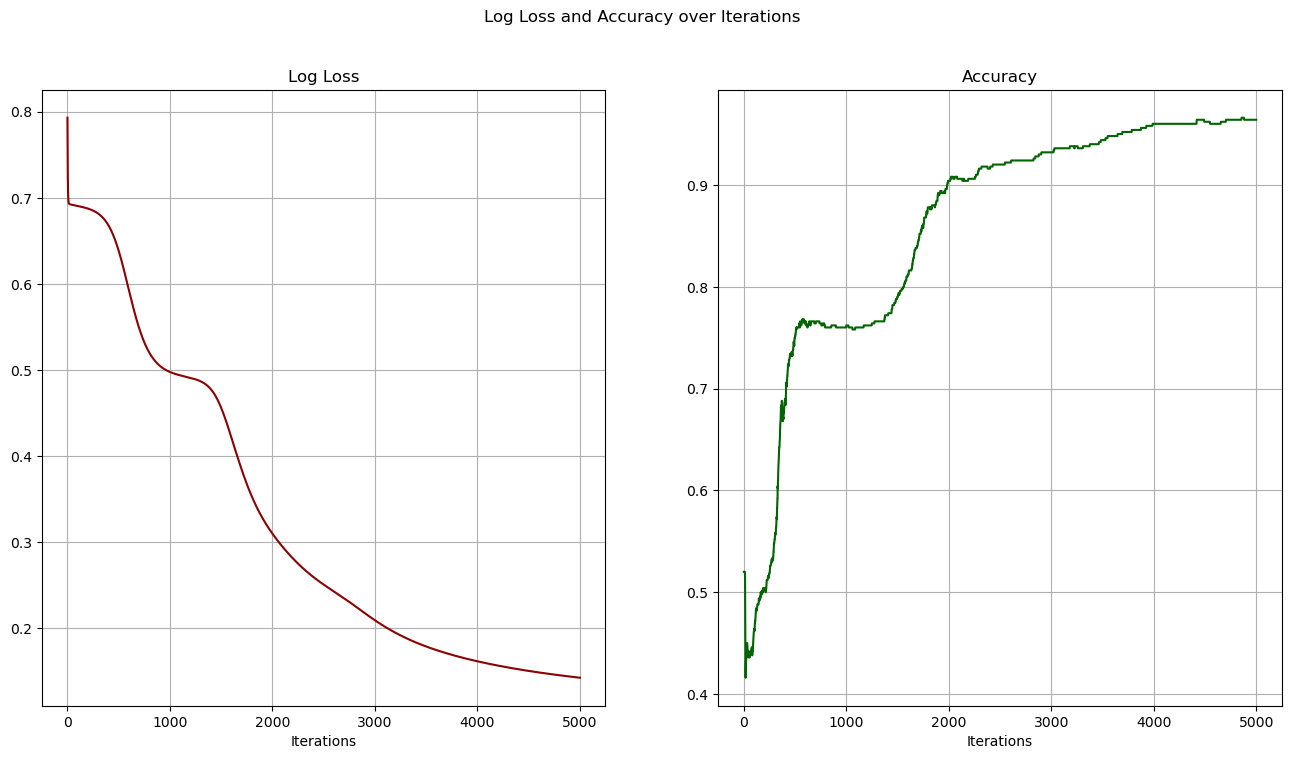

In [5]:
#### Initialize the network parameters

np.random.seed(1241)

W_1 = np.random.uniform(-1,1,size=(3,4))
W_2 = np.random.uniform(-1,1,size=(4))
num_iter = 5000
learning_rate = .001
x_mat = x_mat_full


loss_vals, accuracies = [], []
for i in range(num_iter):
    ### Do a forward computation, and get the gradient
    y_pred, (J_W_1_grad, J_W_2_grad) = forward_pass(W_1, W_2)
    
    ## Update the weight matrices
    W_1 = W_1 - learning_rate*J_W_1_grad 
    W_2 = W_2 - learning_rate*J_W_2_grad
    
    ### Compute the loss and accuracy
    curr_loss = loss_fn(y,y_pred)
    loss_vals.append(curr_loss)
    acc = np.sum((y_pred>=.5) == y)/num_obs
    accuracies.append(acc)

    ## Print the loss and accuracy for every 200th iteration
    if((i%200) == 0):
        print('iteration {}, log loss is {:.4f}, accuracy is {}'.format(
            i, curr_loss, acc
        ))
plot_loss_accuracy(loss_vals, accuracies)

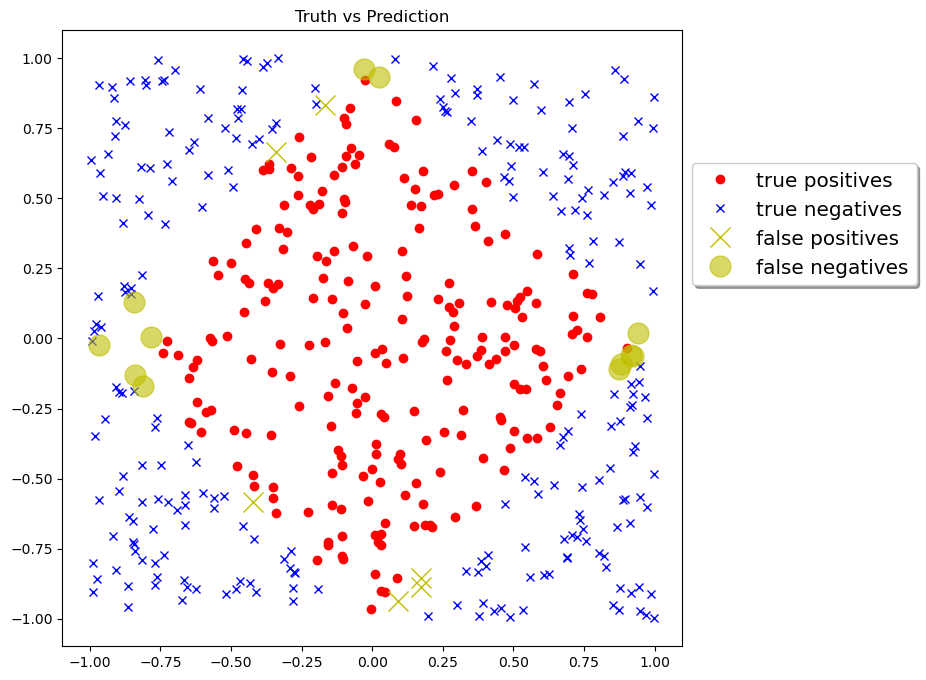

In [6]:
pred1 = (y_pred>=.5)
pred0 = (y_pred<.5)

fig, ax = plt.subplots(figsize=(8, 8))
# true predictions
ax.plot(x_mat[pred1 & (y==1),0],x_mat[pred1 & (y==1),1], 'ro', label='true positives')
ax.plot(x_mat[pred0 & (y==0),0],x_mat[pred0 & (y==0),1], 'bx', label='true negatives')
# false predictions
ax.plot(x_mat[pred1 & (y==0),0],x_mat[pred1 & (y==0),1], 'yx', label='false positives', markersize=15)
ax.plot(x_mat[pred0 & (y==1),0],x_mat[pred0 & (y==1),1], 'yo', label='false negatives', markersize=15, alpha=.6)
ax.set(title='Truth vs Prediction')
ax.legend(bbox_to_anchor=(1, 0.8), fancybox=True, shadow=True, fontsize='x-large');